# Ovrlpy w/o nuclear genes

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import ovrlpy
import polars as pl
from matplotlib_scalebar.scalebar import ScaleBar

In [34]:
import sys

import matplotlib

sys.path.append("../..")

from ovrlpy._plotting import BIH_CMAP as cmap
from ovrlpy._plotting import _plot_signal_integrity

from utils import CM, FONT, finalize_axes, save_kwargs

matplotlib.rc("font", **FONT)

In [ ]:
data_folder = Path(
    "/dh-projects/ag-ishaque/raw_data/tiesmeys-ovrlpy/Xenium-brain-2024/replicate1"
)

In [3]:
with open("nuclear_genes.txt", "r") as f:
    nuclear_genes = [g.strip() for g in f.readlines()]

print(f"Number of nuclear genes: {len(nuclear_genes)}")

Number of nuclear genes: 36


In [9]:
transcripts = ovrlpy.io.read_Xenium(data_folder / "transcripts.parquet")

transcripts_no_nuc = transcripts.filter(
    ~pl.col("gene").is_in(nuclear_genes)
).with_columns(pl.col("gene").cast(pl.String).cast(pl.Categorical))

In [10]:
brain_all = ovrlpy.Ovrlp(transcripts, n_workers=8, random_state=42)

brain_all.process_coordinates(shift=False)
brain_all.fit_transcripts(min_transcripts=20)
brain_all.compute_VSI()

100%|██████████| 54/54 [01:13<00:00,  1.37s/it]


Modeling 30 pseudo-celltype clusters;


100%|██████████| 315/315 [06:22<00:00,  1.21s/it]


In [11]:
brain = ovrlpy.Ovrlp(transcripts_no_nuc, n_workers=8, random_state=42)

brain.process_coordinates(shift=False)
brain.fit_transcripts(min_transcripts=20)
brain.compute_VSI()

determining pseudocells
found 59175 pseudocells
sampling expression:


100%|██████████| 54/54 [01:00<00:00,  1.11s/it]


Modeling 30 pseudo-celltype clusters;


100%|██████████| 315/315 [05:26<00:00,  1.04s/it]


In [12]:
import pickle

with open("xenium_brain_no_nuc.pickle", "wb") as file:
    pickle.dump(brain, file)

with open("xenium_brain.pickle", "wb") as file:
    pickle.dump(brain_all, file)

# Analyse

In [4]:
import pickle

with open("xenium_brain_no_nuc.pickle", "rb") as file:
    brain = pickle.load(file)

with open("xenium_brain.pickle", "rb") as file:
    brain_all = pickle.load(file)

In [5]:
def getsignal(x):
    return x[x > 0]

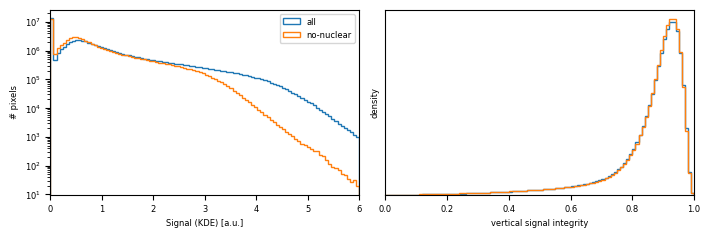

In [6]:
fig, axs = plt.subplots(ncols=2, figsize=(18 * CM, 6 * CM))

# signal
xlim = (0, 6)
hist_kwargs = dict(bins=100, range=xlim, histtype="step")

ax = axs[0]
ax.hist(getsignal(brain_all.signal_map), label="all", **hist_kwargs)
ax.hist(getsignal(brain.signal_map), label="no-nuclear", **hist_kwargs)

ax.legend()
_ = ax.set(ylabel="# pixels", xlabel="Signal (KDE) [a.u.]", xlim=xlim, yscale="log")

# vsi
t = 2

xlim = (0, 1)
hist_kwargs = dict(bins=100, range=xlim, density=True, histtype="step")

ax = axs[1]
ax.hist(brain_all.integrity_map[brain_all.signal_map > t], label="all", **hist_kwargs)
ax.hist(brain.integrity_map[brain.signal_map > t], label="no-nuclear", **hist_kwargs)

_ = ax.set(ylabel="density", xlabel="vertical signal integrity", xlim=xlim, yticks=[])
fig.tight_layout()
fig.savefig("signal_vsi.png", dpi=600)

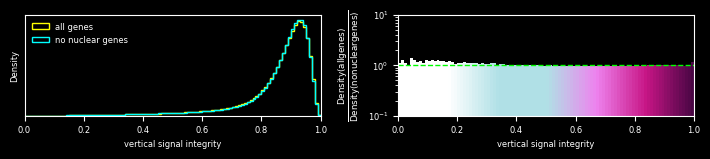

In [40]:
with plt.style.context("dark_background"):
    fig, axs = plt.subplots(ncols=2, figsize=(18 * CM, 4 * CM), sharex=True)

    # signal
    hist_kwargs = dict(bins=100, range=xlim, histtype="step")

    # vsi
    t = 2

    xlim = (0, 1)
    hist_kwargs = dict(bins=100, range=xlim, density=True, histtype="step")

    ax = axs[0]
    density_all, bins, _ = ax.hist(
        brain_all.integrity_map[brain_all.signal_map > t],
        label="all genes",
        color="yellow",
        **hist_kwargs
    )
    density_nuc, bins, _ = ax.hist(
        brain.integrity_map[brain.signal_map > t],
        label="no nuclear genes",
        color="cyan",
        **hist_kwargs
    )

    _ = ax.legend(frameon=False)
    _ = ax.set(
        ylabel="Density", xlabel="vertical signal integrity", xlim=xlim, yticks=[]
    )

    # ratio
    hist_quotient = density_nuc / density_all
    bars = axs[1].bar(bins[:-1], hist_quotient, width=0.01, align="edge", lw=0)
    for bar, color in zip(bars, cmap(bins[:-1])):
        bar.set_color(color)

    axs[1].set(xlabel="vertical signal integrity", yscale="log", ylim=(0.1, 10))
    axs[1].set_ylabel(
        r"$\frac{\mathrm{Density(all genes)}}{\mathrm{Density(no nuclear genes)}}$",
        fontsize=9,
    )
    axs[1].hlines(1, 0, 1, linestyles="dashed", color="lime", lw=1)

    fig.tight_layout()
    fig.savefig("vsi_ratio.svg", **save_kwargs)

In [15]:
vsi_scalebar = dict(dx=1, units="um", frameon=False, color="w", loc="lower left")

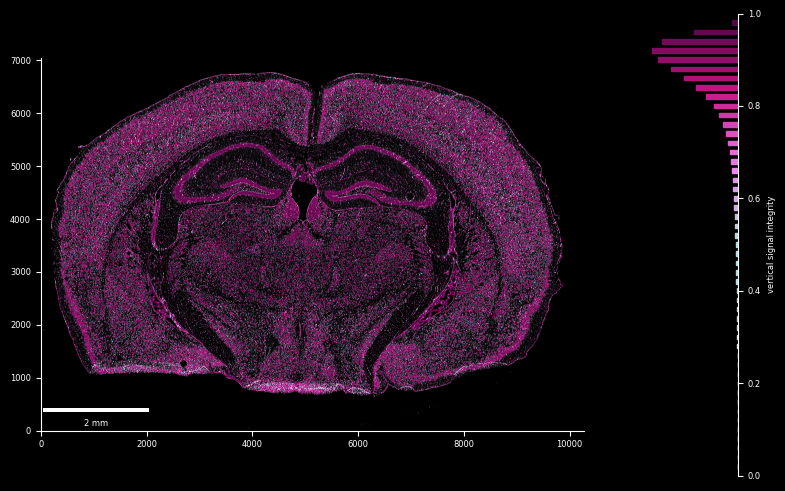

In [16]:
fig = ovrlpy.plot_signal_integrity(brain_all, scalebar=vsi_scalebar)

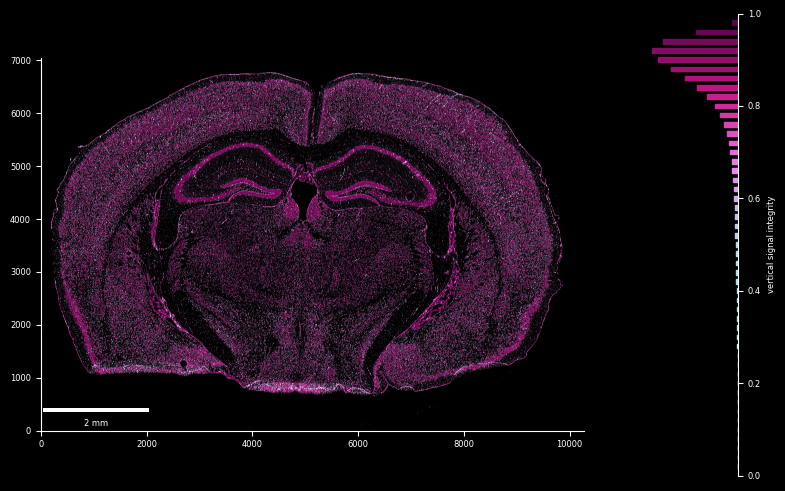

In [17]:
fig = ovrlpy.plot_signal_integrity(brain, scalebar=vsi_scalebar)

In [18]:
vsi_map = brain_all.integrity_map
vsi_nonuc_map = brain.integrity_map

# check that they have the same shape
vsi_nonuc_map.shape == vsi_map.shape

True

In [19]:
keep = (brain.signal_map > t) & (brain_all.signal_map > t)

vsi = vsi_map[keep]
vsi_nuc = vsi_nonuc_map[keep]

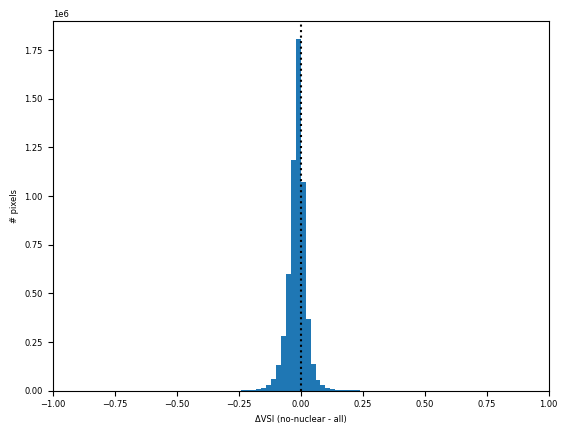

In [20]:
fig, ax = plt.subplots()
_ = ax.hist(vsi_nuc - vsi, bins=100, range=(-1, 1))
_ = ax.axvline(0, ls=":", c="black")
_ = ax.set(ylabel="# pixels", xlabel="ΔVSI (no-nuclear - all)", xlim=(-1, 1))

In [21]:
doublets = brain_all.detect_doublets(min_signal=3, integrity_sigma=2)

In [22]:
delta_vsi = vsi_nonuc_map - vsi_map

delta_vsi_doublets = delta_vsi[doublets["y"].to_pandas(), doublets["x"].to_pandas()]

doublets = doublets.with_columns(delta_vsi=delta_vsi_doublets)

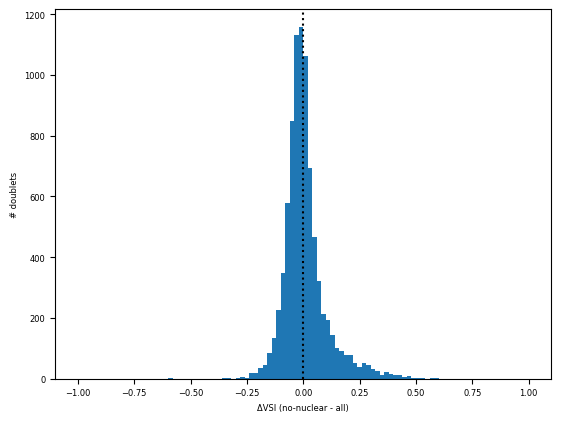

In [23]:
fig, ax = plt.subplots()
_ = ax.hist(delta_vsi_doublets, bins=100, range=(-1, 1))
_ = ax.axvline(0, ls=":", c="black")
_ = ax.set(xlabel="ΔVSI (no-nuclear - all)", ylabel="# doublets")

In [24]:
t_ = 0.2

different_doublets = (delta_vsi_doublets > t_).sum()

print("# doublets:", doublets.shape[0])
print("# doublets with large ΔVSI:", different_doublets)
print(f"# doublets w/ ΔVSI > {t_:.1f}:", different_doublets / doublets.shape[0])

# doublets: 8425
# doublets with large ΔVSI: 423
# doublets w/ ΔVSI > 0.2: 0.05020771513353116


## Visualize

In [25]:
from math import ceil, floor

import tifffile

In [26]:
um_p_px = 0.2125  # for the tif

In [41]:
def get_range(x, r, scale=um_p_px):
    return slice(int(floor((x - r) / scale)), int(ceil((x + r) / scale)))


def plot_doublet(ovrlp, ovrlp2, imgs, x, y, window_size=40, figsize=(9 * CM, 5 * CM)):
    xmin, xmax = int(x) - window_size, int(x) + window_size
    ymin, ymax = int(y) - window_size, int(y) + window_size
    xrange = slice(xmin, xmax)
    yrange = slice(ymin, ymax)

    signal_integrity = ovrlp.integrity_map[yrange, xrange]
    signal_strength = ovrlp.signal_map[yrange, xrange]

    signal_integrity2 = ovrlp2.integrity_map[yrange, xrange]
    signal_strength2 = ovrlp2.signal_map[yrange, xrange]

    roi_transcripts = ovrlp.subset_transcripts(x, y, window_size=window_size).sort("z")

    _, embedding_color = ovrlp.transform_transcripts(roi_transcripts)
    roi_transcripts = roi_transcripts.with_columns(RGB=embedding_color)

    return plot_transcripts(
        imgs,
        roi_transcripts,
        signal_integrity,
        signal_strength,
        signal_integrity2,
        signal_strength2,
        x,
        y,
        window_size,
        figsize,
    )


def plot_transcripts(
    imgs,
    roi_transcripts,
    signal_integrity,
    signal_strength,
    signal_integrity2,
    signal_strength2,
    x,
    y,
    window_size,
    figsize=(9 * CM, 5 * CM),
):
    fig, axs = plt.subplots(nrows=1, ncols=8, figsize=figsize)

    scatter_kwargs = dict(s=1, lw=0, rasterized=True)

    ax_integrity = axs[2]
    _plot_signal_integrity(ax_integrity, signal_integrity, signal_strength, t)
    finalize_axes(ax_integrity, window_size, window_size, window_size)
    ax_integrity.set_title("VSI")
    ax_integrity.set_facecolor("black")

    ax_integrity2 = axs[3]
    _plot_signal_integrity(ax_integrity2, signal_integrity2, signal_strength2, t)
    finalize_axes(ax_integrity2, window_size, window_size, window_size)
    ax_integrity2.set_title("VSI (no-nuc)")
    ax_integrity2.set_facecolor("black")

    ax_bottom = axs[1]
    roi_bottom = roi_transcripts.filter(pl.col("z") < pl.col("z_center")).reverse()
    ax_bottom.scatter(
        x=roi_bottom["x"], y=roi_bottom["y"], c=roi_bottom["RGB"], **scatter_kwargs
    )
    finalize_axes(ax_bottom, x, y, window_size)
    ax_bottom.set_title("bottom")

    ax_top = axs[0]
    roi_top = roi_transcripts.filter(pl.col("z") > pl.col("z_center"))
    ax_top.scatter(x=roi_top["x"], y=roi_top["y"], c=roi_top["RGB"], **scatter_kwargs)
    finalize_axes(ax_top, x, y, window_size)
    ax_top.set_title("top")

    for (name, im), ax in zip(imgs.items(), axs[4:]):
        ax.imshow(im[get_range(y, window_size), get_range(x, window_size)])
        ax.invert_xaxis()
        ax.set(xticks=[], yticks=[], title=f"z={name}")

    return fig

In [46]:
tif = tifffile.TiffReader(data_folder / "morphology.ome.tif")
images = {str(i): tif.series[0].pages[i].asarray(out="memmap") for i in range(4, 8)}

In [47]:
doublets = doublets.sort("delta_vsi", descending=True)

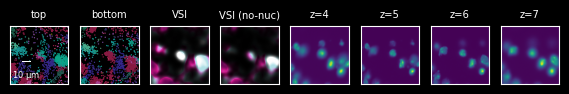

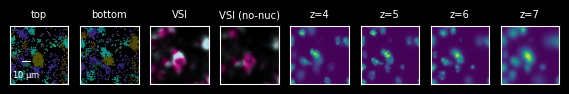

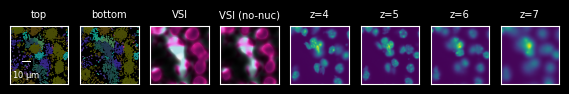

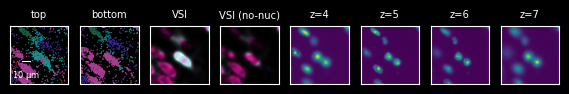

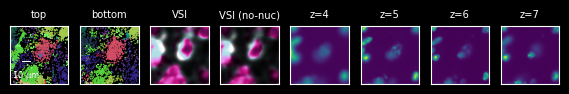

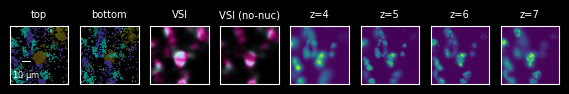

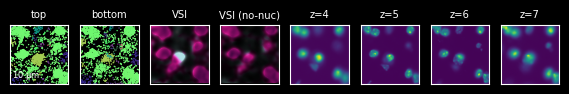

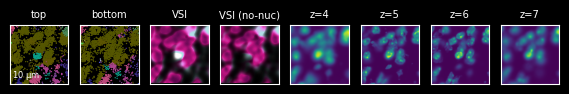

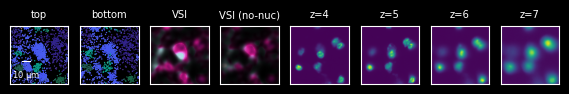

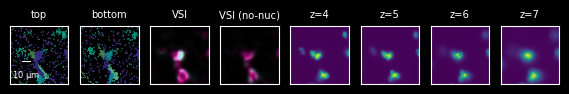

In [50]:
with plt.style.context("dark_background"):
    for i in range(10):
        x, y = doublets["x", "y"].row(i)
        fig = plot_doublet(
            brain_all,
            brain,
            images,
            x,
            y,
            window_size=30,
            figsize=(18 * CM, 3 * CM),
        )
        fig.axes[0].add_artist(
            ScaleBar(
                1,
                units="um",
                length_fraction=0.2,
                loc="lower left",
                frameon=False,
                color="w",
            )
        )

        fig.savefig(f"doublet_{i + 1}.svg", **save_kwargs)

In [51]:
del images
tif.close()

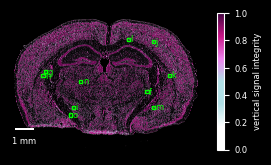

In [36]:
alphabet = "abcdefghijklmnopqrstuvwxyz"

fig = ovrlpy.plot_signal_integrity(
    brain_all,
    histogram=False,
    scalebar=dict(
        dx=1,
        units="um",
        frameon=False,
        color="w",
        loc="lower left",
        length_fraction=0.1,
    ),
    figsize=(8 * CM, 4.5 * CM),
)

ax = fig.axes[0]

ax.set_axis_off()

for i in range(10):
    x, y = doublets["x", "y"].row(i)

    ax.text(x + 100, y, alphabet[i + 5], color="lime", fontsize=6, va="center")
    ax.scatter(x, y, marker="s", s=5, edgecolors="lime", facecolors="None", lw=1)


fig.savefig("signal_integrity_rectangles.svg", **save_kwargs)

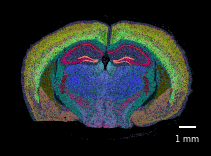

In [38]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(7 * CM, 4.5 * CM))
    _ = ovrlpy.plot_tissue(
        brain_all,
        ax=ax,
        scalebar=dict(
            dx=1,
            units="um",
            frameon=False,
            color="w",
            loc="lower right",
            length_fraction=0.1,
        ),
        **scatter_kwargs,
    )
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)
    fig.savefig("localmaxima.svg", **save_kwargs)

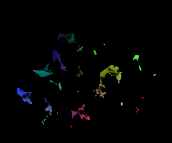

In [39]:
with plt.style.context("dark_background"):
    scatter_kwargs = dict(s=1, lw=0)

    fig, ax = plt.subplots(figsize=(5 * CM, 5 * CM))
    _ = ovrlpy.plot_umap(brain_all, ax=ax, scatter_kwargs=scatter_kwargs)
    ax.set_axis_off()
    ax.collections[0].set_rasterized(True)

    for t in fig.axes[0].texts:
        t.set(color="white")

    fig.savefig("umap.svg", **save_kwargs)